In [6]:
import os, sys

import IPython.display as ipd

path= '/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation'
sys.path.append(path)
path= '/Users/sbielfel/Nextcloud2/phase_retrieval/explore'
sys.path.append(path)


import pandas as pd
import gemmi
import matplotlib.pyplot as plt
import meteor
import reciprocalspaceship as rs
from occupancy import *
from plotting3d import *
%load_ext autoreload 
%autoreload 2

from generate_objects import run_scaleit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
folderloc =  '../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
dataloc_light = folderloc + "7_30ns/30ns_deposit.mtz"
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)




# Overview over data

In [4]:
ds_dark

I-obs      SIGI-obs  R-free-flags  F-obs-filtered  \
H  K  L                                                              
0  0  6   284157.84375  28358.560547             6     3381.124023   
      8     114.540741     38.163765            17       67.087746   
      10   4017.811523    139.221115             8      421.545776   
      12  46658.433594   1461.593262            11     1435.483765   
      14   1479.636963     58.852287             0      255.786545   
...                ...           ...           ...             ...   
57 14 5            NaN           NaN             1             NaN   
      6            NaN           NaN             6             NaN   
0  0  2            NaN           NaN           NaN             NaN   
   1  1            NaN           NaN           NaN             NaN   
      2            NaN           NaN           NaN             NaN   

          SIGF-obs-filtered      F-model  PHIF-model      2FOFCWT  PH2FOFCWT  \
H  K  L                                                                        
0  0  6          186.983047  3328.107178         0.0  3773.437256        0.0   
      8           14.345318     8.001706         0.0     0.535461        0.0   
      10           7.316233   441.704254         0.0   471.327728        0.0   
      12          22.552881  1184.225586       180.0  1559.282227      180.0   
      14           5.098086   183.673569       180.0     154.3396      180.0   
...                     ...          ...         ...          ...        ...   
57 14 5                 NaN          NaN         NaN          NaN        NaN   
      6                 NaN          NaN         NaN          NaN        NaN   
0  0  2                 NaN          NaN         NaN  6173.225586        0.0   
   1  1                 NaN          NaN         NaN  3479.721191       90.0   
      2                 NaN          NaN         NaN  1941.794922      -90.0   

          2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H  K  L                                                             
0  0  6       3773.437256                0.0   79.419266       0.0  
      8          0.535461                0.0    8.313123     180.0  
      10       471.327728                0.0   26.647619     180.0  
      12      1559.282227              180.0  279.940491     180.0  
      14         154.3396              180.0   43.214062       0.0  
...                   ...                ...         ...       ...  
57 14 5               NaN                NaN         NaN       NaN  
      6               NaN                NaN         NaN       NaN  
0  0  2               NaN                NaN         NaN       NaN  
   1  1               NaN                NaN         NaN       NaN  
      2               NaN                NaN         NaN       NaN  

[418451 rows x 13 columns]

In [5]:

ds_light 

IMEAN       SIGIMEAN           F       SIGF       KFEXTR  \
H  K L                                                                   
0  0 2          NaN            NaN         NaN        NaN          NaN   
     4          NaN            NaN         NaN        NaN          NaN   
     6   563041.625  124030.234375  733.373047  87.899185  3107.084473   
     7 -1661.612183    1027.905151    12.38824   8.876429          NaN   
     8  -470.827209     346.035034    7.571723   5.376757    58.114021   
...             ...            ...         ...        ...          ...   
35 3 3          NaN            NaN         NaN        NaN          NaN   
     4          NaN            NaN         NaN        NaN          NaN   
   4 0          NaN            NaN         NaN        NaN          NaN   
     1          NaN            NaN         NaN        NaN          NaN   
     2          NaN            NaN         NaN        NaN          NaN   

        SIGKFEXTR  R-free-flags      F-model  PHIF-model      2FOFCWT  \
H  K L                                                                  
0  0 2        NaN           NaN          NaN         NaN  6650.478516   
     4        NaN            14          NaN         NaN  1927.483765   
     6  16.496628             6  3358.235596         0.0  3301.962158   
     7        NaN           NaN          NaN         NaN          NaN   
     8  40.554333            17   168.217529         0.0     2.425961   
...           ...           ...          ...         ...          ...   
35 3 3        NaN             6          NaN         NaN          NaN   
     4        NaN            19          NaN         NaN          NaN   
   4 0        NaN            12          NaN         NaN          NaN   
     1        NaN            10          NaN         NaN          NaN   
     2        NaN             0          NaN         NaN          NaN   

        PH2FOFCWT  2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H  K L                                                                       
0  0 2        0.0              NaN                NaN         NaN       NaN  
     4        0.0              NaN                NaN         NaN       NaN  
     6        0.0      3301.962158                0.0  752.040527       0.0  
     7        NaN              NaN                NaN         NaN       NaN  
     8        0.0         2.425961                0.0  124.879761     180.0  
...           ...              ...                ...         ...       ...  
35 3 3        NaN              NaN                NaN         NaN       NaN  
     4        NaN              NaN                NaN         NaN       NaN  
   4 0        NaN              NaN                NaN         NaN       NaN  
     1        NaN              NaN                NaN         NaN       NaN  
     2        NaN              NaN                NaN         NaN       NaN  

[96220 rows x 15 columns]

In [22]:
# dataloc_light = folderloc + "7_30ns/30ns_deposit.mtz"
dataloc_light = "../photolyase_masks/8oy8.mtz"
ds_light = rs.read_mtz(dataloc_light)
ds_light

FreeR_flag        IMEAN     SIGIMEAN           FP      SIGFP  \
H  K L                                                                 
0  0 2         NaN          NaN          NaN          NaN        NaN   
     4         NaN          NaN          NaN          NaN        NaN   
     6           1     563042.0     124030.0  3107.080078  16.496599   
     7           0 -1661.609985  1027.910034          NaN        NaN   
     8           1  -470.826996   346.035004    58.113998  40.554298   
...            ...          ...          ...          ...        ...   
35 3 3         NaN          NaN          NaN          NaN        NaN   
     4         NaN          NaN          NaN          NaN        NaN   
   4 0         NaN          NaN          NaN          NaN        NaN   
     1         NaN          NaN          NaN          NaN        NaN   
     2         NaN          NaN          NaN          NaN        NaN   

                FC  PHIC          FWT  PHWT      DELFWT  DELPHWT  
H  K L                                                            
0  0 2         NaN   NaN   6650.47998   0.0         NaN      NaN  
     4         NaN   NaN   1927.47998   0.0         NaN      NaN  
     6  3358.23999   0.0  3301.959961   0.0  752.041016      0.0  
     7         NaN   NaN          NaN   NaN         NaN      NaN  
     8  168.218002   0.0      2.42596   0.0  124.879997    180.0  
...            ...   ...          ...   ...         ...      ...  
35 3 3         NaN   NaN          NaN   NaN         NaN      NaN  
     4         NaN   NaN          NaN   NaN         NaN      NaN  
   4 0         NaN   NaN          NaN   NaN         NaN      NaN  
     1         NaN   NaN          NaN   NaN         NaN      NaN  
     2         NaN   NaN          NaN   NaN         NaN      NaN  

[96220 rows x 11 columns]

In [4]:
names_dict = {
    # "photolyase10": "Photolyase 10 ns", 
    "photolyase30": "Photolyase 30 ns", 
    # "synthetic_cistrans": "rsEGFP2 (synth)",
    # "real_cistrans": "rsEGFP2 (meteor)",
    # "mpro": "MPRO (meteor)",
    # "doeke": "EFX protein (Doeke)",
}
import reciprocalspaceship as rs
def struc2realspace(struc, hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(struc, high_resolution_limit=hs_limit)
    struc_vals=rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F","PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    # struc_vals_real = struc_vals.transform_f_phi_to_map("sf")

    struc_vals_real = np.fft.ifftn(struc_vals_grid).real
    return struc_vals_real

from generate_objects import get_pdb_pairs
for name in names_dict.keys():    
    pdb_pair = get_pdb_pairs(name)
    parent = "/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/"
    fname_dark = f"{parent}synthetic_data/{pdb_pair[0]}.pdb"
    fname_mix = f"{parent}synthetic_data/{pdb_pair[1]}.pdb"
    struc_dark = gemmi.read_structure(fname_dark)
    struc_light = gemmi.read_structure(fname_mix)
    density_darkT = struc2realspace(struc_dark, 1.2, 0)
    density_lightT = struc2realspace(struc_light, 1.2, 0)
print(density_darkT.shape)
print(density_lightT.shape)
unit = np.array((
    struc_dark.cell.a,
    struc_dark.cell.b,
    struc_dark.cell.c
))

(180, 300, 432)
(180, 300, 432)


In [62]:
def get_pdb_pos(pdbname):
    st = gemmi.read_structure(pdbname)
    st.remove_alternative_conformations()
    st.remove_hydrogens()
    st.remove_waters()
    st.remove_ligands_and_waters()
    st.remove_empty_chains()
    pos_list = np.array([st.cell.fractionalize(rca.atom.pos).tolist()   for rca in st[0].all()])
    print((st.spacegroup_hm))
    print((st.cell.is_compatible_with_spacegroup(gemmi.SpaceGroup("P 1"))))
    st.setup_cell_images()
    # print(st.find_nearest
    st.setup_cell_images()
    pos_list = np.array([st.cell.fractionalize(rca.atom.pos).tolist()   for rca in st[0].all()])
    print(len(st))
    return pos_list

In [63]:
struc_dark = gemmi.read_structure(fname_dark)
pos_list =get_pdb_pos(fname_dark)

dataloc_light = "../photolyase_masks/8oy8.mtz"
mtz_dark = gemmi.read_mtz_file(dataloc_dark)
mtz_light = gemmi.read_mtz_file(dataloc_light)
size = mtz_dark.get_size_for_hkl(sample_rate=1.2)

fouplex_dark = mtz_dark.get_f_phi_on_grid('F-model', "PHIF-model",size)
fouplex_light = mtz_light.get_f_phi_on_grid('FC', "PHIC",size)
def get_real(fouplex):
    fouplex = np.array(fouplex)
    mask = np.isfinite(fouplex)
    fouplex[~mask] = 0
    return np.fft.ifftn(fouplex).real 
realplex_dark = get_real(fouplex_dark)
realplex_light = get_real(fouplex_light)
protein_shape = realplex.shape
frac_mask, frac_list = np.divmod(pos_list, 1)
# d2_points, d2_mask = make_points(frac_list, 0, imlen, frac_mask)
sizes = np.array(protein_shape)[[2,1,0]]
pos2 = pos_list[:,[2,1,0]]


P 21 21 21
True
1


120
(-0.001736111111111111, 0.9982638888888888, 0.9975, -0.0025)


interactive(children=(IntSlider(value=0, description='f0', max=119), Output()), _dom_classes=('widget-interact…

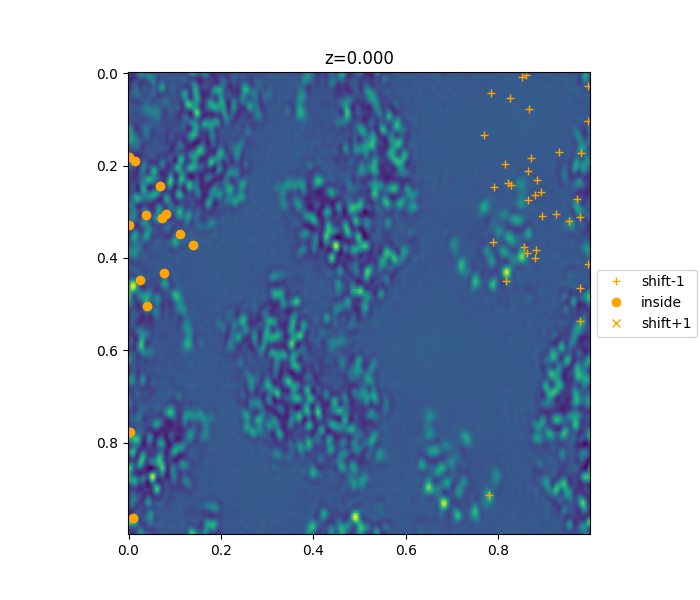

In [43]:
# pos_trans = pos2[:,[2,1,0]]
# unwrap_trans = unwrap_v2[[2,1,0]].transpose(0,3,2,1)
# print(motif.shape,motif.transpose(2,1,0).shape,
#     unwrap_v2.shape,unwrap_trans.shape)
from output_eval import mtz_comp
%matplotlib widget
pos2 = pos_list[:,[1,0,2]]
_ = mtz_comp(pos2,realplex_light)
# _ = mtz_comp(pos_list,realplex_dark, )

In [67]:
dark_f = 'F-model'
dark_phi = "PHIF-model"

# dark_f = 'F'
# dark_phi = "PHI"
# dark_phi = "PHI"
from meteor import rsmap
map_dark = rsmap.Map.read_mtz_file(
    dataloc_dark,
    amplitude_column=dark_f,
    phase_column=dark_phi,
    # uncertainty_column=dark_sigma,
)
map_density = map_dark.to_3d_numpy_map(map_sampling=3)

In [71]:
map_density.shape

(180, 300, 432)

interactive(children=(IntSlider(value=90, description='f0', max=179), Output()), _dom_classes=('widget-interac…

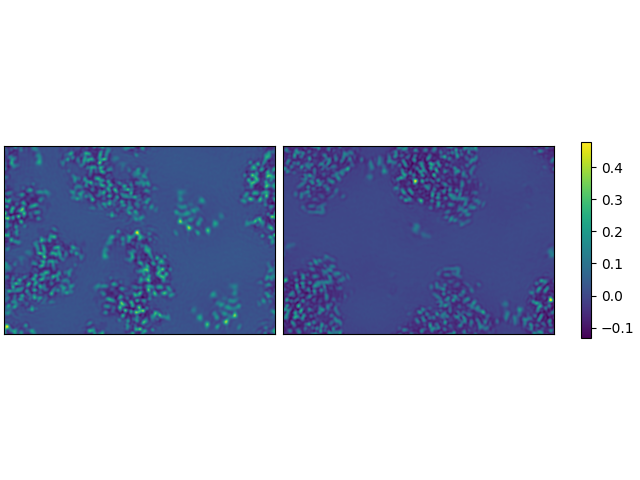

(<Figure size 640x480 with 3 Axes>, array([<Axes: >, <Axes: >], dtype=object))

In [77]:
from output_eval import panels_3d 
panels_3d((map_density,
          realplex_dark))
# _ = mtz_comp(pos2,map_density.transpose(2,1,0))
